# Sample Spaces, Events & Axioms

**Track:** Foundations of Probability (Topic 1 of 4)  
**Difficulty:** Foundational  
**Prerequisites:** Sequences & Limits (formalCalculus)  
**formalStatistics** — [formalstatistics.com](https://www.formalstatistics.com)

This notebook builds probability from the ground up — starting with experiments, outcomes, and sample spaces, then formalizing events as sets, and arriving at the Kolmogorov axioms that govern all of probability theory. We prove the basic consequences of the axioms (complement rule, inclusion-exclusion, continuity of probability) and close with a bridge to ML: why these axioms underpin every probabilistic model you'll ever train.

**ML motivation:** Every probabilistic model — from naïve Bayes to diffusion models — assigns probabilities to events. The Kolmogorov axioms are the contract that every valid probability distribution must satisfy. Understanding this contract tells you what probability *can* do, what it *cannot* do, and where models can silently violate the rules.

**Notebook structure:**
1. Experiments, Outcomes & Sample Spaces
2. Events as Sets — The Algebra of Outcomes
3. Sigma-Algebras: Why We Need Them
4. The Kolmogorov Axioms
5. Consequences of the Axioms
6. Combinatorial Probability: Counting and Equally Likely Outcomes
7. Conditional Probability & Independence (Preview)
8. Connections to ML
9. Computational Verification

**Publication-quality figures:** All matplotlib figures use consistent styling for export to `public/images/topics/sample-spaces/`.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch, Circle, FancyBboxPatch
from matplotlib_venn import venn2, venn3
import matplotlib.patches as mpatches
from itertools import combinations, chain
from math import comb, factorial
from typing import Set, FrozenSet, List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# Publication-quality figure defaults
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 150,
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.15,
})

# Color palette — consistent across all formalStatistics notebooks
C = {
    'primary': '#2563eb',    # Blue — main distributions/sets
    'secondary': '#7c3aed',  # Purple — secondary sets
    'accent': '#059669',     # Green — success/valid
    'warning': '#d97706',    # Amber — caution
    'danger': '#dc2626',     # Red — complement/error
    'muted': '#6b7280',      # Gray — axes, annotations
    'lt_blue': '#dbeafe',    # Light blue — shaded regions
    'lt_green': '#d1fae5',   # Light green — regions
    'lt_red': '#fee2e2',     # Light red — complement regions
    'lt_purple': '#ede9fe',  # Light purple — regions
    'lt_amber': '#fef3c7',   # Light amber — regions
}

print("Setup complete — formalStatistics sample spaces notebook ready.")
print(f"NumPy {np.__version__}, Matplotlib {plt.matplotlib.__version__}")

Setup complete — formalStatistics sample spaces notebook ready.
NumPy 2.4.4, Matplotlib 3.10.8


---

## 1. Experiments, Outcomes & Sample Spaces

### 1.1 The Idea

Probability is the mathematics of uncertainty. Before we can assign probabilities to anything, we need a precise language for describing *what could happen*. That language starts with three terms:

- An **experiment** (or **random experiment**) is any process whose outcome is not known in advance.
- An **outcome** is one specific result of the experiment.
- The **sample space** $\Omega$ is the set of all possible outcomes.

These are not deep concepts — they're agreements about notation. But getting them right is essential, because every probability statement we'll ever make is a statement about subsets of $\Omega$.

**Definition 1 (Sample Space).** The *sample space* of a random experiment is the set $\Omega$ whose elements are the possible outcomes of the experiment. An individual outcome $\omega \in \Omega$ is called a *sample point*.

### 1.2 Examples of Sample Spaces

Let's build some sample spaces, from finite to countably infinite to uncountable.

| Experiment | Sample Space $\Omega$ | Size |
|---|---|---|
| Flip a fair coin | $\{H, T\}$ | Finite, $|\Omega| = 2$ |
| Roll a six-sided die | $\{1, 2, 3, 4, 5, 6\}$ | Finite, $|\Omega| = 6$ |
| Roll two dice (ordered) | $\{(i,j) : i,j \in \{1,\ldots,6\}\}$ | Finite, $|\Omega| = 36$ |
| Flip a coin until heads | $\{H, TH, TTH, TTTH, \ldots\}$ | Countably infinite |
| Pick a real number in $[0,1]$ | $[0,1]$ | Uncountable |
| Lifetime of a light bulb | $[0, \infty)$ | Uncountable |

The first four examples are the bread and butter of introductory probability. The last two are where things get interesting — and where we'll eventually need sigma-algebras and measure theory to do probability properly.

**Why the sample space matters for ML:** When you specify a probabilistic model, you are (implicitly or explicitly) choosing a sample space. A Bernoulli model says $\Omega = \{0, 1\}$. A Gaussian model says $\Omega = \mathbb{R}$. A language model says $\Omega$ is the set of all possible token sequences. Getting the sample space wrong — or not thinking about it at all — leads to models that assign probability to impossible events or fail to cover the actual data-generating process.

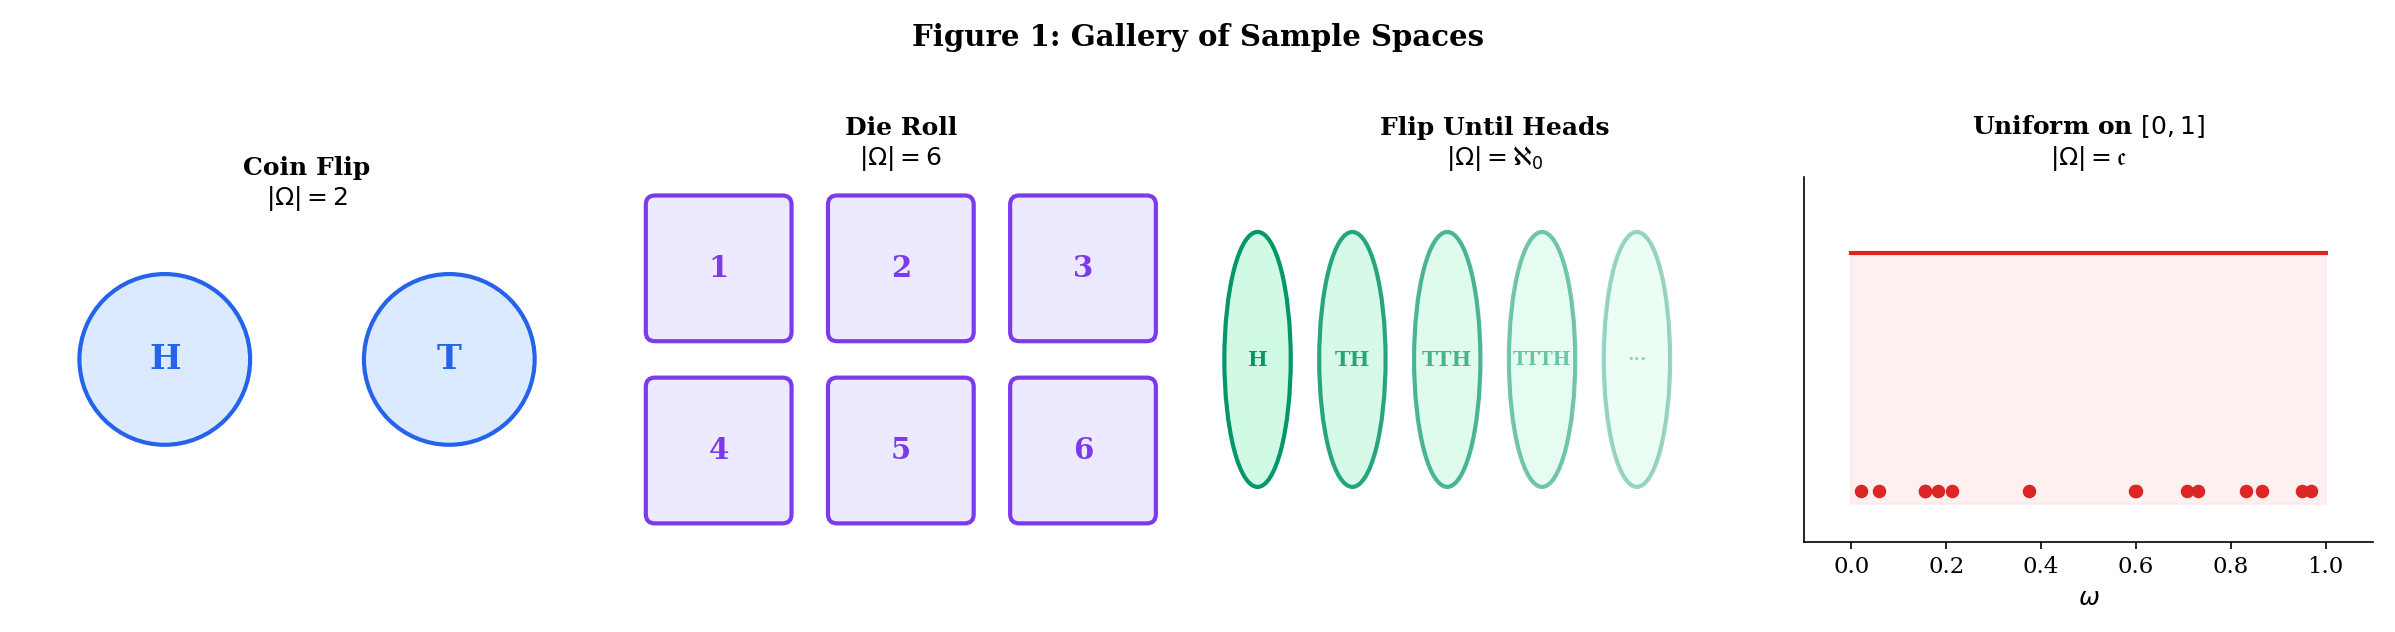

In [2]:
# ── Figure 1: Gallery of sample spaces ──────────────────────────────────────
np.random.seed(42)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Panel 1: Coin flip — finite, |Ω| = 2
ax = axes[0]
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 0.5)
ax.set_aspect('equal')
for i, label in enumerate(['H', 'T']):
    circle = Circle((i, 0), 0.3, fill=True, facecolor=C['lt_blue'],
                     edgecolor=C['primary'], linewidth=2)
    ax.add_patch(circle)
    ax.text(i, 0, label, ha='center', va='center', fontsize=16, fontweight='bold',
            color=C['primary'])
ax.set_title('Coin Flip\n$|\Omega| = 2$', fontsize=12)
ax.axis('off')

# Panel 2: Die roll — finite, |Ω| = 6
ax = axes[1]
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 1.5)
ax.set_aspect('equal')
positions = [(0, 1), (1, 1), (2, 1), (0, 0), (1, 0), (2, 0)]
for (x, y), val in zip(positions, range(1, 7)):
    rect = FancyBboxPatch((x - 0.35, y - 0.35), 0.7, 0.7, boxstyle="round,pad=0.05",
                          facecolor=C['lt_purple'], edgecolor=C['secondary'], linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, str(val), ha='center', va='center', fontsize=14, fontweight='bold',
            color=C['secondary'])
ax.set_title('Die Roll\n$|\Omega| = 6$', fontsize=12)
ax.axis('off')

# Panel 3: Coin flips until heads — countably infinite
ax = axes[2]
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 0.5)
labels = ['H', 'TH', 'TTH', 'TTTH', '···']
for i, label in enumerate(labels):
    alpha = 1.0 - 0.15 * i
    circle = Circle((i, 0), 0.35, fill=True, facecolor=C['lt_green'],
                     edgecolor=C['accent'], linewidth=2, alpha=alpha)
    ax.add_patch(circle)
    ax.text(i, 0, label, ha='center', va='center', fontsize=10 if i < 3 else 9,
            fontweight='bold', color=C['accent'], alpha=alpha)
ax.set_title('Flip Until Heads\n' r'$|\Omega| = \aleph_0$', fontsize=12)
ax.axis('off')

# Panel 4: Uniform on [0,1] — uncountable
ax = axes[3]
x = np.linspace(0, 1, 200)
ax.fill_between(x, 0, 1, color=C['lt_red'], alpha=0.5)
ax.plot(x, np.ones_like(x), color=C['danger'], linewidth=2)
samples = np.random.uniform(0, 1, 15)
ax.scatter(samples, np.zeros_like(samples) + 0.05, color=C['danger'], s=30, zorder=5)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.15, 1.3)
ax.set_xlabel('$\omega$')
ax.set_title('Uniform on $[0,1]$\n$|\Omega| = \mathfrak{c}$', fontsize=12)
ax.set_yticks([])

plt.suptitle('Figure 1: Gallery of Sample Spaces', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample-spaces-gallery.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 2. Events as Sets — The Algebra of Outcomes

### 2.1 What Is an Event?

An *event* is any collection of outcomes — a subset of $\Omega$. We say event $A$ *occurs* if the actual outcome $\omega$ of the experiment satisfies $\omega \in A$.

**Definition 2 (Event).** An *event* is a subset $A \subseteq \Omega$. The event $A$ *occurs* if the outcome $\omega$ of the experiment belongs to $A$.

Special events:
- The **certain event** $\Omega$ always occurs.
- The **impossible event** $\emptyset$ never occurs.
- A **simple event** $\{\omega\}$ consists of a single outcome.

**Example 1 (Die roll).** Let $\Omega = \{1, 2, 3, 4, 5, 6\}$.
- $A = \{2, 4, 6\}$ is the event "roll an even number."
- $B = \{5, 6\}$ is the event "roll at least 5."
- $A \cap B = \{6\}$ is the event "roll an even number that is at least 5."
- $A \cup B = \{2, 4, 5, 6\}$ is the event "roll an even number *or* at least 5."
- $A^c = \{1, 3, 5\}$ is the event "do not roll an even number" (i.e., roll odd).

### 2.2 Set Operations as Logical Connectives

The correspondence between set operations and logical statements about events is exact:

| Set Operation | Notation | Meaning |
|---|---|---|
| Union | $A \cup B$ | $A$ or $B$ (or both) occurs |
| Intersection | $A \cap B$ | Both $A$ and $B$ occur |
| Complement | $A^c$ | $A$ does not occur |
| Set difference | $A \setminus B = A \cap B^c$ | $A$ occurs but $B$ does not |
| Subset | $A \subseteq B$ | If $A$ occurs, then $B$ occurs |
| Disjoint | $A \cap B = \emptyset$ | $A$ and $B$ cannot both occur |

These are the building blocks. De Morgan's laws connect them:
$$A^c \cup B^c = (A \cap B)^c \qquad \text{and} \qquad A^c \cap B^c = (A \cup B)^c$$

In words: "not both" equals "not one or not the other," and "neither" equals "not either." De Morgan's laws generalize to arbitrary collections of events — including countably infinite unions and intersections, which is where sigma-algebras enter the picture.

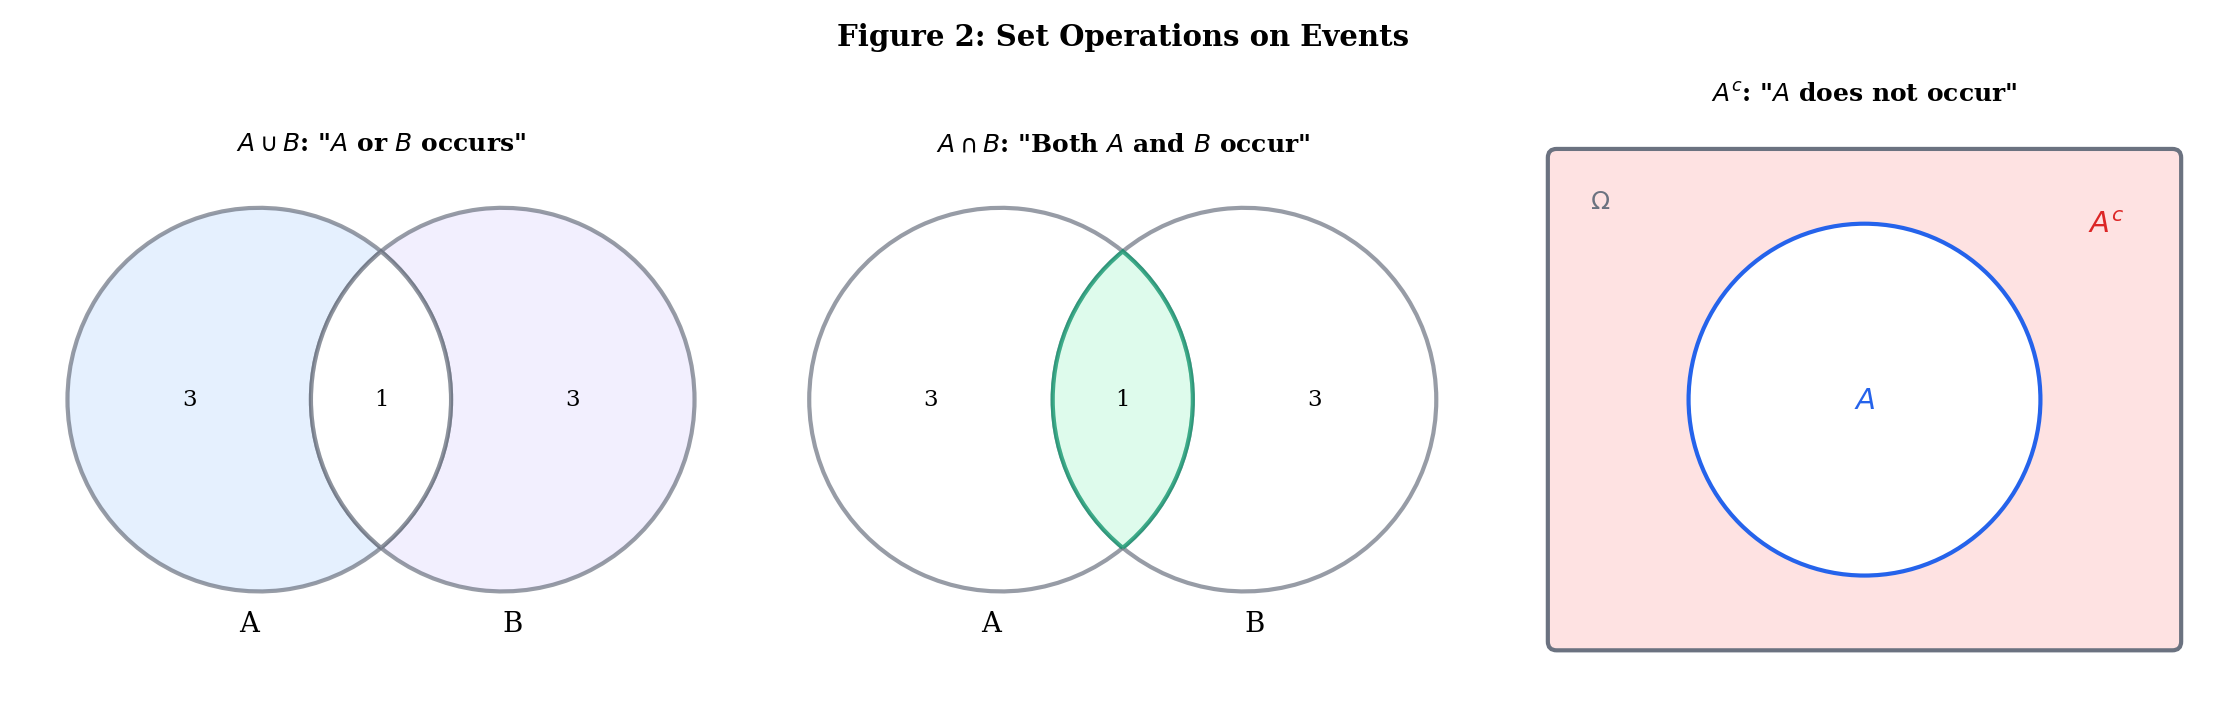

In [3]:
# ── Figure 2: Venn diagram of set operations ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: A ∪ B
ax = axes[0]
v = venn2(subsets=(3, 3, 1), set_labels=('A', 'B'), ax=ax,
          set_colors=(C['lt_blue'], C['lt_purple']),
          alpha=0.7)
for pid in ['10', '01', '11']:
    if v.get_patch_by_id(pid):
        v.get_patch_by_id(pid).set_edgecolor(C['muted'])
        v.get_patch_by_id(pid).set_linewidth(2)
ax.set_title('$A \cup B$: "$A$ or $B$ occurs"', fontsize=12)

# Panel 2: A ∩ B
ax = axes[1]
v = venn2(subsets=(3, 3, 1), set_labels=('A', 'B'), ax=ax,
          set_colors=('white', 'white'),
          alpha=0.7)
for pid in ['10', '01']:
    if v.get_patch_by_id(pid):
        v.get_patch_by_id(pid).set_facecolor('white')
        v.get_patch_by_id(pid).set_edgecolor(C['muted'])
        v.get_patch_by_id(pid).set_linewidth(2)
if v.get_patch_by_id('11'):
    v.get_patch_by_id('11').set_facecolor(C['lt_green'])
    v.get_patch_by_id('11').set_edgecolor(C['accent'])
    v.get_patch_by_id('11').set_linewidth(2)
ax.set_title('$A \cap B$: "Both $A$ and $B$ occur"', fontsize=12)

# Panel 3: A^c
ax = axes[2]
# Draw sample space rectangle
rect = FancyBboxPatch((-0.7, -0.55), 1.4, 1.1, boxstyle="round,pad=0.02",
                      facecolor=C['lt_red'], edgecolor=C['muted'], linewidth=2)
ax.add_patch(rect)
circle = Circle((0, 0), 0.4, facecolor='white', edgecolor=C['primary'], linewidth=2)
ax.add_patch(circle)
ax.text(0, 0, '$A$', ha='center', va='center', fontsize=14, color=C['primary'],
        fontweight='bold')
ax.text(0.55, 0.4, '$A^c$', ha='center', va='center', fontsize=14, color=C['danger'],
        fontweight='bold')
ax.text(-0.6, 0.45, '$\Omega$', ha='center', va='center', fontsize=12, color=C['muted'])
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.65, 0.65)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('$A^c$: "$A$ does not occur"', fontsize=12)

plt.suptitle('Figure 2: Set Operations on Events', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('event-set-operations.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 3. Sigma-Algebras: Why We Need Them

### 3.1 The Problem with "All Subsets"

For finite sample spaces, life is simple: the collection of events is just the power set $\mathcal{P}(\Omega) = \{A : A \subseteq \Omega\}$. With a six-sided die, $\mathcal{P}(\Omega)$ has $2^6 = 64$ subsets, and we can assign a probability to each one without trouble.

For uncountable sample spaces like $\Omega = [0,1]$, things break. It turns out there is no way to assign a probability to *every* subset of $[0,1]$ while satisfying the Kolmogorov axioms — this is the content of the **Vitali construction** (1905), which produces a non-measurable set. The details are fascinating but require measure theory we haven't developed yet; we'll encounter them in the *Measure-Theoretic Probability* topic later in the curriculum.

The fix is elegant: instead of trying to assign probabilities to all subsets, we work only with a well-behaved collection of subsets called a **sigma-algebra** (or $\sigma$-algebra).

### 3.2 Definition

**Definition 3 ($\sigma$-algebra).** A $\sigma$*-algebra* (or $\sigma$*-field*) on a set $\Omega$ is a collection $\mathcal{F} \subseteq \mathcal{P}(\Omega)$ satisfying:

1. $\Omega \in \mathcal{F}$  (the sample space is an event)
2. If $A \in \mathcal{F}$, then $A^c \in \mathcal{F}$  (closed under complements)
3. If $A_1, A_2, A_3, \ldots \in \mathcal{F}$, then $\bigcup_{n=1}^{\infty} A_n \in \mathcal{F}$  (closed under countable unions)

These three properties have immediate consequences. By De Morgan's law, closure under complements + countable unions gives closure under countable intersections for free:
$$\bigcap_{n=1}^{\infty} A_n = \left(\bigcup_{n=1}^{\infty} A_n^c\right)^c \in \mathcal{F}$$

And since $\emptyset = \Omega^c$, the empty set is always in $\mathcal{F}$.

**Remark 1.** The word "countable" in axiom (3) is doing heavy lifting. A collection closed under *finite* unions but not countable unions is called an *algebra* (or *field*) of sets. The upgrade from algebra to $\sigma$-algebra is exactly what we need for limit theorems — taking limits of sequences of events requires countable set operations.

### 3.3 Examples

**Example 2 (The trivial and discrete $\sigma$-algebras).**
- The *trivial* $\sigma$-algebra $\mathcal{F} = \{\emptyset, \Omega\}$ is the smallest possible — we can only say "something happened" or "nothing happened."
- The *discrete* $\sigma$-algebra $\mathcal{F} = \mathcal{P}(\Omega)$ is the largest — every subset is an event. This works for countable $\Omega$.

**Example 3 (A nontrivial $\sigma$-algebra on a finite set).**  
Let $\Omega = \{1, 2, 3, 4\}$. Consider $\mathcal{F} = \{\emptyset, \{1,2\}, \{3,4\}, \Omega\}$.  
Check: (1) $\Omega \in \mathcal{F}$ ✓. (2) $\{1,2\}^c = \{3,4\} \in \mathcal{F}$ ✓. (3) All unions of members yield members ✓.  
This $\sigma$-algebra "sees" the partition $\{\{1,2\}, \{3,4\}\}$ but cannot distinguish 1 from 2 or 3 from 4. It encodes partial information — a theme that becomes central in conditional probability and filtrations.

**Example 4 (The Borel $\sigma$-algebra).**  
On $\Omega = \mathbb{R}$, the *Borel $\sigma$-algebra* $\mathcal{B}(\mathbb{R})$ is the smallest $\sigma$-algebra containing all open intervals $(a, b)$. It contains all open sets, all closed sets, all countable intersections of open sets ($G_\delta$ sets), all countable unions of closed sets ($F_\sigma$ sets), and so on. This is the standard $\sigma$-algebra for probability on $\mathbb{R}$ and is the one you'll use 99% of the time in practice.

**Why this matters for ML:** When you say "$X \sim \mathcal{N}(\mu, \sigma^2)$," you are implicitly working with the Borel $\sigma$-algebra on $\mathbb{R}$. The measurability requirement — that a random variable must pull Borel sets back to events in your $\sigma$-algebra — is what makes statements like "$P(X \leq t)$" well-defined. We'll formalize this in the *Random Variables & Distributions* topic.

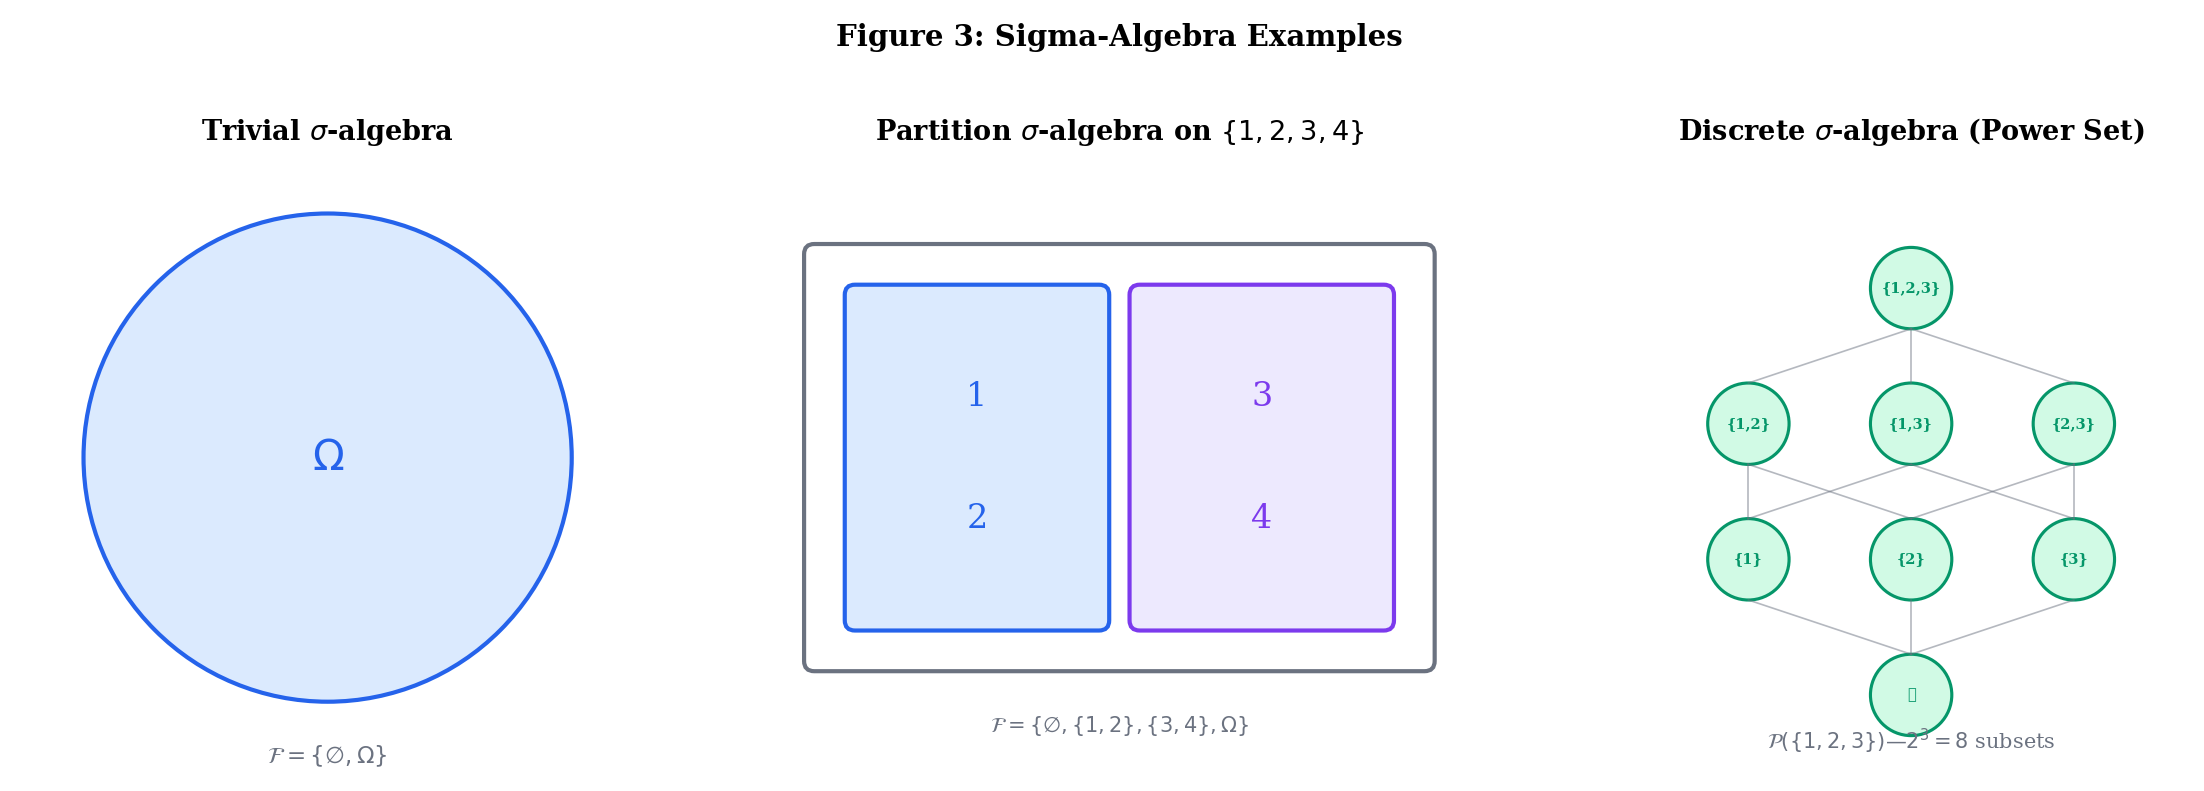

In [4]:
# ── Figure 3: Sigma-algebra containment hierarchy ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Trivial sigma-algebra
ax = axes[0]
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
outer = Circle((0, 0), 1.2, fill=True, facecolor=C['lt_blue'], edgecolor=C['primary'],
               linewidth=2, linestyle='-')
ax.add_patch(outer)
ax.text(0, 0, '$\Omega$', ha='center', va='center', fontsize=20, color=C['primary'],
        fontweight='bold')
ax.text(0, -1.5, '$\mathcal{F} = \{\emptyset, \Omega\}$', ha='center', fontsize=11,
        color=C['muted'])
ax.set_title('Trivial $\sigma$-algebra', fontsize=13)
ax.axis('off')

# Panel 2: Partition sigma-algebra on {1,2,3,4}
ax = axes[1]
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
# Outer rectangle for Omega
rect = FancyBboxPatch((-1.5, -1.0), 3.0, 2.0, boxstyle="round,pad=0.05",
                      facecolor='white', edgecolor=C['muted'], linewidth=2)
ax.add_patch(rect)
# Left block {1,2}
left = FancyBboxPatch((-1.3, -0.8), 1.2, 1.6, boxstyle="round,pad=0.05",
                       facecolor=C['lt_blue'], edgecolor=C['primary'], linewidth=2)
ax.add_patch(left)
ax.text(-0.7, 0.3, '1', ha='center', va='center', fontsize=16, color=C['primary'])
ax.text(-0.7, -0.3, '2', ha='center', va='center', fontsize=16, color=C['primary'])
# Right block {3,4}
right = FancyBboxPatch((0.1, -0.8), 1.2, 1.6, boxstyle="round,pad=0.05",
                        facecolor=C['lt_purple'], edgecolor=C['secondary'], linewidth=2)
ax.add_patch(right)
ax.text(0.7, 0.3, '3', ha='center', va='center', fontsize=16, color=C['secondary'])
ax.text(0.7, -0.3, '4', ha='center', va='center', fontsize=16, color=C['secondary'])
ax.text(0, -1.35, '$\mathcal{F} = \{\emptyset, \{1,2\}, \{3,4\}, \Omega\}$',
        ha='center', fontsize=10, color=C['muted'])
ax.set_title('Partition $\sigma$-algebra on $\{1,2,3,4\}$', fontsize=13)
ax.axis('off')

# Panel 3: Power set (discrete) on {1,2,3}
ax = axes[2]
ax.set_xlim(-2, 2)
ax.set_ylim(-0.5, 4)

# Hasse diagram of P({1,2,3})
levels = {
    0: [('∅', 0)],
    1: [('{1}', -1.2), ('{2}', 0), ('{3}', 1.2)],
    2: [('{1,2}', -1.2), ('{1,3}', 0), ('{2,3}', 1.2)],
    3: [('{1,2,3}', 0)],
}
node_positions = {}
for level, nodes in levels.items():
    for label, x in nodes:
        node_positions[label] = (x, level)
        circle = Circle((x, level), 0.3, facecolor=C['lt_green'], edgecolor=C['accent'],
                        linewidth=1.5)
        ax.add_patch(circle)
        ax.text(x, level, label, ha='center', va='center', fontsize=7,
                color=C['accent'], fontweight='bold')

# Draw edges (Hasse diagram)
edges = [
    ('∅', '{1}'), ('∅', '{2}'), ('∅', '{3}'),
    ('{1}', '{1,2}'), ('{1}', '{1,3}'),
    ('{2}', '{1,2}'), ('{2}', '{2,3}'),
    ('{3}', '{1,3}'), ('{3}', '{2,3}'),
    ('{1,2}', '{1,2,3}'), ('{1,3}', '{1,2,3}'), ('{2,3}', '{1,2,3}'),
]
for a, b in edges:
    xa, ya = node_positions[a]
    xb, yb = node_positions[b]
    ax.plot([xa, xb], [ya + 0.3, yb - 0.3], color=C['muted'], linewidth=0.8, alpha=0.5)

ax.text(0, -0.4, '$\mathcal{P}(\{1,2,3\}) — 2^3 = 8$ subsets', ha='center',
        fontsize=10, color=C['muted'])
ax.set_title('Discrete $\sigma$-algebra (Power Set)', fontsize=13)
ax.set_aspect('equal')
ax.axis('off')

plt.suptitle('Figure 3: Sigma-Algebra Examples', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sigma-algebra-examples.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. The Kolmogorov Axioms

### 4.1 The Axioms

We now have the stage ($\Omega$), the actors ($\mathcal{F}$), and we need the script: a function that assigns a number to each event. Kolmogorov's axioms (1933) tell us what properties this function must have.

**Definition 4 (Probability Measure).** A *probability measure* on a measurable space $(\Omega, \mathcal{F})$ is a function $P : \mathcal{F} \to [0,1]$ satisfying:

**Axiom 1 (Non-negativity).** For every $A \in \mathcal{F}$, $P(A) \geq 0$.

**Axiom 2 (Normalization).** $P(\Omega) = 1$.

**Axiom 3 (Countable Additivity).** If $A_1, A_2, A_3, \ldots \in \mathcal{F}$ are pairwise disjoint (i.e., $A_i \cap A_j = \emptyset$ for all $i \neq j$), then
$$P\left(\bigcup_{n=1}^{\infty} A_n\right) = \sum_{n=1}^{\infty} P(A_n).$$

The triple $(\Omega, \mathcal{F}, P)$ is called a *probability space*.

That's it. Three axioms. Every theorem in probability theory — the law of large numbers, the central limit theorem, Bayes' rule, the convergence of your neural network's training loss — follows from these three axioms plus the machinery of analysis.

**Remark 2 (Why countable additivity?).** Axiom 3 demands countable additivity, not mere finite additivity. This is the axiom that makes limit theorems possible. If we only required $P(A_1 \cup \cdots \cup A_n) = P(A_1) + \cdots + P(A_n)$ for finite collections, we could not take limits of sequences of events — and without limits, no convergence theorems, no law of large numbers, no central limit theorem. The jump from "finitely many" to "countably many" is small in notation but enormous in mathematical power. It is precisely the bridge from algebra to $\sigma$-algebra, and from combinatorial probability to probability theory.

### 4.2 The Fair Die — A Concrete Probability Space

**Example 5.** Roll a fair die. The probability space is:
- $\Omega = \{1, 2, 3, 4, 5, 6\}$
- $\mathcal{F} = \mathcal{P}(\Omega)$ (all 64 subsets)
- $P(\{\omega\}) = 1/6$ for each $\omega$, extended by additivity: $P(A) = |A|/6$

Check the axioms: (1) $P(A) = |A|/6 \geq 0$ ✓. (2) $P(\Omega) = 6/6 = 1$ ✓. (3) For disjoint $A, B$: $P(A \cup B) = |A \cup B|/6 = (|A| + |B|)/6 = P(A) + P(B)$ ✓.

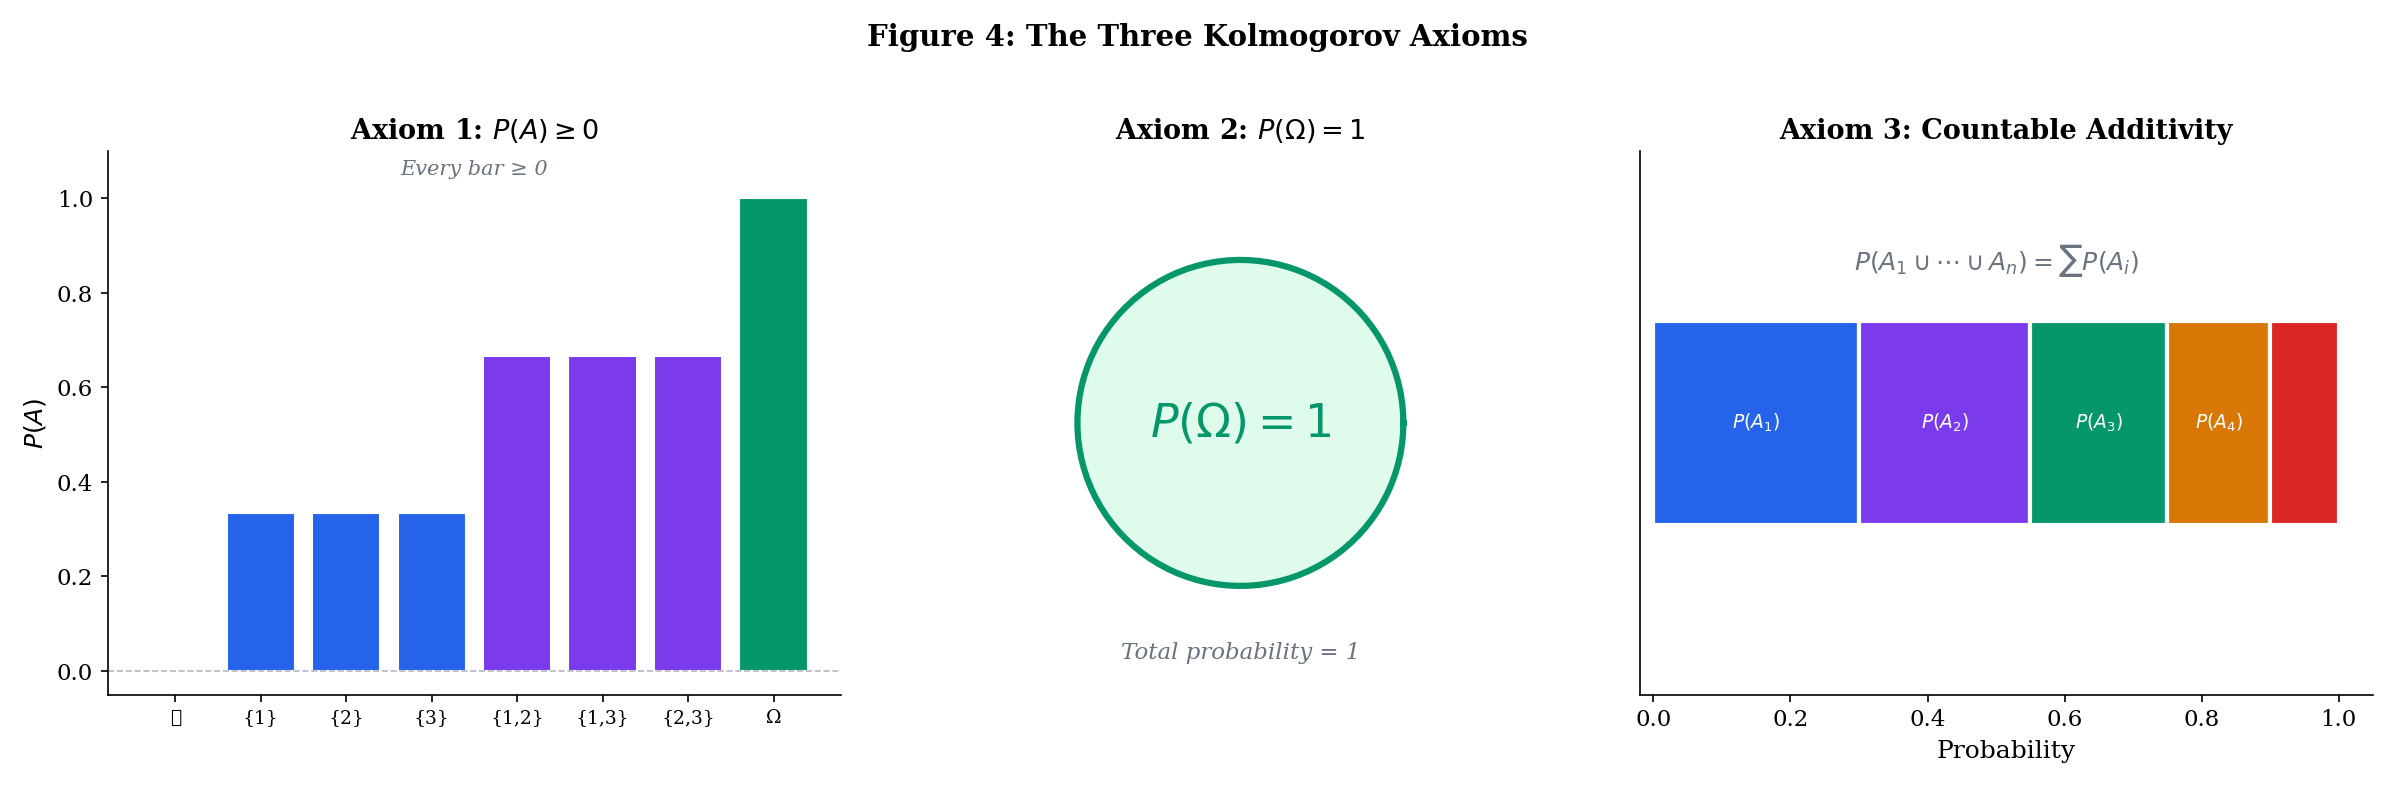

In [5]:
# ── Figure 4: Visual representation of the Kolmogorov axioms ─────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Non-negativity — bar chart of P(A) for all events of a 3-sided "die"
ax = axes[0]
omega = [1, 2, 3]
events = ['∅', '{1}', '{2}', '{3}', '{1,2}', '{1,3}', '{2,3}', 'Ω']
probs = [0, 1/3, 1/3, 1/3, 2/3, 2/3, 2/3, 1]
colors = [C['muted']] + [C['primary']]*3 + [C['secondary']]*3 + [C['accent']]
ax.bar(range(len(events)), probs, color=colors, edgecolor='white', linewidth=1)
ax.set_xticks(range(len(events)))
ax.set_xticklabels(events, fontsize=9)
ax.set_ylabel('$P(A)$')
ax.set_ylim(-0.05, 1.1)
ax.axhline(y=0, color=C['muted'], linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Axiom 1: $P(A) \geq 0$', fontsize=13)
ax.text(3.5, 1.05, 'Every bar ≥ 0', ha='center', fontsize=10, color=C['muted'],
        style='italic')

# Panel 2: Normalization — P(Ω) = 1
ax = axes[1]
theta = np.linspace(0, 2*np.pi, 100)
ax.fill(0.9*np.cos(theta), 0.9*np.sin(theta), color=C['lt_green'], alpha=0.7)
ax.plot(0.9*np.cos(theta), 0.9*np.sin(theta), color=C['accent'], linewidth=3)
ax.text(0, 0, '$P(\Omega) = 1$', ha='center', va='center', fontsize=22,
        fontweight='bold', color=C['accent'])
ax.text(0, -1.3, 'Total probability = 1', ha='center', fontsize=11, color=C['muted'],
        style='italic')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Axiom 2: $P(\Omega) = 1$', fontsize=13)

# Panel 3: Countable additivity — disjoint pieces sum
ax = axes[2]
# Stack of disjoint blocks
block_probs = [0.30, 0.25, 0.20, 0.15, 0.10]
block_colors = [C['primary'], C['secondary'], C['accent'], C['warning'], C['danger']]
bottom = 0
for i, (p, c) in enumerate(zip(block_probs, block_colors)):
    ax.barh(0, p, left=bottom, height=0.6, color=c, edgecolor='white', linewidth=2)
    if p >= 0.15:
        ax.text(bottom + p/2, 0, f'$P(A_{i+1})$', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
    bottom += p

ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.8, 0.8)
ax.set_xlabel('Probability')
ax.set_yticks([])

# Brace annotation
ax.annotate('$P(A_1 \cup \cdots \cup A_n) = \sum P(A_i)$',
            xy=(0.5, 0.45), fontsize=12, ha='center', color=C['muted'],
            fontweight='bold')
ax.set_title('Axiom 3: Countable Additivity', fontsize=13)

plt.suptitle('Figure 4: The Three Kolmogorov Axioms', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kolmogorov-axioms.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 5. Consequences of the Axioms

Everything in this section is *derived* from the three axioms — no additional assumptions needed. This is the engine of probability theory: a small axiomatic base generating a rich body of results.

### 5.1 The Complement Rule

**Theorem 1 (Complement Rule).** For any event $A \in \mathcal{F}$,
$$P(A^c) = 1 - P(A).$$

*Proof.* Since $A$ and $A^c$ are disjoint and $A \cup A^c = \Omega$, Axiom 3 gives $P(A) + P(A^c) = P(\Omega) = 1$ (by Axiom 2). Rearranging: $P(A^c) = 1 - P(A)$. $\square$

**Corollary 1.** $P(\emptyset) = 0$.

*Proof.* Take $A = \Omega$ in Theorem 1: $P(\emptyset) = P(\Omega^c) = 1 - P(\Omega) = 1 - 1 = 0$. $\square$

### 5.2 Monotonicity

**Theorem 2 (Monotonicity).** If $A \subseteq B$, then $P(A) \leq P(B)$.

*Proof.* Write $B = A \cup (B \setminus A)$, where $A$ and $B \setminus A$ are disjoint. By Axiom 3:
$$P(B) = P(A) + P(B \setminus A) \geq P(A)$$
since $P(B \setminus A) \geq 0$ by Axiom 1. $\square$

### 5.3 The Addition Rule (Inclusion-Exclusion for Two Events)

**Theorem 3 (Addition Rule).** For any events $A, B \in \mathcal{F}$,
$$P(A \cup B) = P(A) + P(B) - P(A \cap B).$$

*Proof.* Decompose $A \cup B$ into three pairwise disjoint pieces:
$$A \cup B = (A \setminus B) \cup (A \cap B) \cup (B \setminus A).$$
By Axiom 3:
$$P(A \cup B) = P(A \setminus B) + P(A \cap B) + P(B \setminus A).$$
Now, $A = (A \setminus B) \cup (A \cap B)$ (disjoint), so $P(A) = P(A \setminus B) + P(A \cap B)$, giving $P(A \setminus B) = P(A) - P(A \cap B)$. Similarly $P(B \setminus A) = P(B) - P(A \cap B)$. Substituting:
$$P(A \cup B) = [P(A) - P(A \cap B)] + P(A \cap B) + [P(B) - P(A \cap B)] = P(A) + P(B) - P(A \cap B). \quad \square$$

### 5.4 Inclusion-Exclusion (General)

**Theorem 4 (Inclusion-Exclusion).** For events $A_1, \ldots, A_n \in \mathcal{F}$,
$$P\left(\bigcup_{i=1}^n A_i\right) = \sum_{i} P(A_i) - \sum_{i<j} P(A_i \cap A_j) + \sum_{i<j<k} P(A_i \cap A_j \cap A_k) - \cdots + (-1)^{n+1} P(A_1 \cap \cdots \cap A_n).$$

We prove this by induction on $n$. The base case $n = 2$ is Theorem 3. The inductive step applies Theorem 3 to $\left(\bigcup_{i=1}^{n-1} A_i\right) \cup A_n$ and uses the distributive law $\left(\bigcup_{i=1}^{n-1} A_i\right) \cap A_n = \bigcup_{i=1}^{n-1} (A_i \cap A_n)$. We'll spare the full induction here — the pattern is combinatorial and the bookkeeping, while not conceptually hard, is notationally heavy. The full proof is in any measure-theoretic probability text (see Billingsley, Chapter 2).

### 5.5 Boole's Inequality (Union Bound)

**Theorem 5 (Union Bound / Boole's Inequality).** For any countable collection of events $A_1, A_2, \ldots \in \mathcal{F}$,
$$P\left(\bigcup_{n=1}^{\infty} A_n\right) \leq \sum_{n=1}^{\infty} P(A_n).$$

*Proof.* Define $B_1 = A_1$ and $B_n = A_n \setminus \bigcup_{k=1}^{n-1} A_k$ for $n \geq 2$. The $B_n$ are pairwise disjoint, $\bigcup B_n = \bigcup A_n$, and $B_n \subseteq A_n$. By countable additivity and monotonicity:
$$P\left(\bigcup_{n=1}^{\infty} A_n\right) = P\left(\bigcup_{n=1}^{\infty} B_n\right) = \sum_{n=1}^{\infty} P(B_n) \leq \sum_{n=1}^{\infty} P(A_n). \quad \square$$

**Why the union bound matters for ML:** The union bound is the workhorse of PAC learning theory. When you want to say "the probability that *any* of $n$ hypotheses overfits is at most $\delta$," you assign each hypothesis an error budget of $\delta/n$ and apply Boole's inequality. It's crude but universal — and it's the starting point for tighter tools like Rademacher complexity and VC dimension that you'll encounter in formalML.

### 5.6 Continuity of Probability

**Theorem 6 (Continuity of Probability).** Let $A_1, A_2, \ldots \in \mathcal{F}$.

(a) If $A_n \uparrow A$ (i.e., $A_1 \subseteq A_2 \subseteq \cdots$ and $A = \bigcup_{n=1}^{\infty} A_n$), then
$$P(A) = \lim_{n \to \infty} P(A_n).$$

(b) If $A_n \downarrow A$ (i.e., $A_1 \supseteq A_2 \supseteq \cdots$ and $A = \bigcap_{n=1}^{\infty} A_n$), then
$$P(A) = \lim_{n \to \infty} P(A_n).$$

*Proof of (a).* Define $B_1 = A_1$ and $B_n = A_n \setminus A_{n-1}$ for $n \geq 2$. The $B_n$ are pairwise disjoint and $\bigcup_{k=1}^n B_k = A_n$. So $\bigcup_{n=1}^{\infty} B_n = A$. By countable additivity:
$$P(A) = \sum_{n=1}^{\infty} P(B_n) = \lim_{N \to \infty} \sum_{n=1}^{N} P(B_n) = \lim_{N \to \infty} P(A_N).$$

*Proof of (b).* Apply part (a) to $A_n^c \uparrow A^c$, then use the complement rule. $\square$

**Remark 3 (Continuity of probability is equivalent to countable additivity).** Given finite additivity, countable additivity is *equivalent* to continuity from below (Theorem 6a). This is a deep fact — it means Axiom 3 is really saying "probability is a continuous set function," which connects our probability axioms directly to the continuity of limits from formalCalculus.

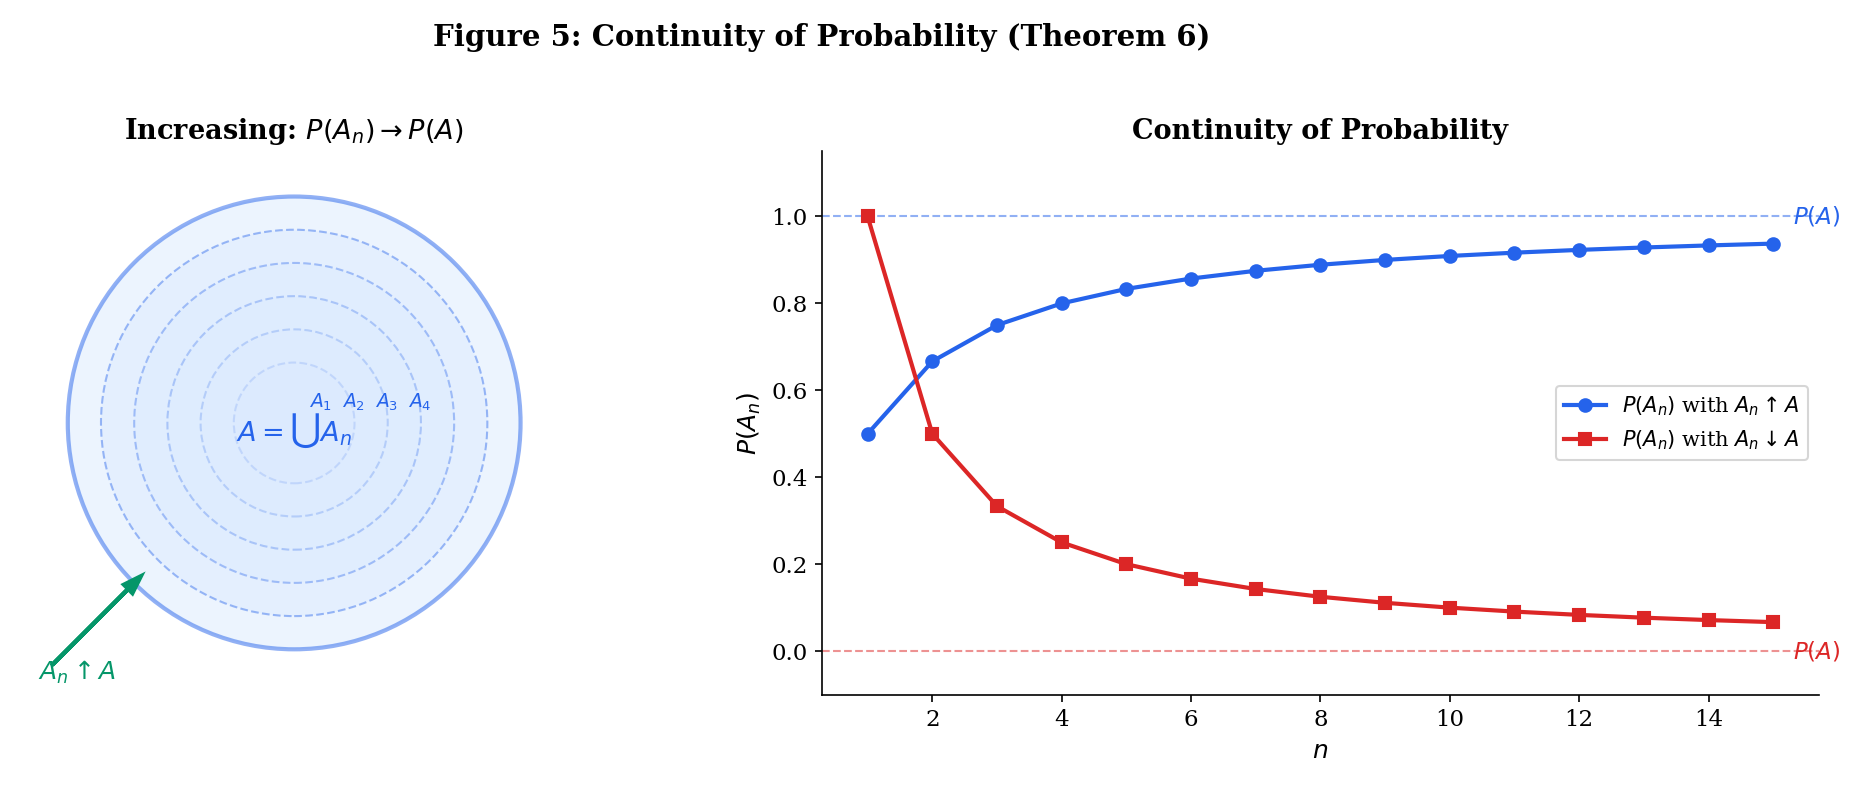

In [6]:
# ── Figure 5: Continuity of probability — nested sets ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: A_n ↑ A (increasing sequence)
ax = axes[0]
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal')
n_circles = 6
alphas = np.linspace(0.15, 0.5, n_circles)
radii = np.linspace(0.4, 1.5, n_circles)
for i in range(n_circles - 1, -1, -1):
    circle = Circle((0, 0), radii[i], facecolor=C['lt_blue'], edgecolor=C['primary'],
                     linewidth=2 if i == n_circles - 1 else 1,
                     alpha=alphas[i],
                     linestyle='-' if i == n_circles - 1 else '--')
    ax.add_patch(circle)
    if i < 4:
        ax.text(radii[i] - 0.15, 0.1, f'$A_{i+1}$', fontsize=9, color=C['primary'],
                ha='right')

ax.text(0, -0.05, r'$A = \bigcup A_n$', ha='center', va='center', fontsize=13,
        color=C['primary'], fontweight='bold')
ax.arrow(-1.6, -1.6, 0.5, 0.5, head_width=0.08, color=C['accent'], linewidth=2)
ax.text(-1.7, -1.7, r'$A_n \uparrow A$', fontsize=12, color=C['accent'],
        fontweight='bold')
ax.set_title(r'Increasing: $P(A_n) \to P(A)$', fontsize=13)
ax.axis('off')

# Panel 2: Probability values converging
ax = axes[1]
n_vals = np.arange(1, 16)
# P(A_n) = 1 - 1/(n+1) for a sequence increasing to P(A) = 1
p_increasing = 1 - 1 / (n_vals + 1)
p_decreasing = 1 / (n_vals)

ax.plot(n_vals, p_increasing, 'o-', color=C['primary'], linewidth=2, markersize=6,
        label=r'$P(A_n)$ with $A_n \uparrow A$')
ax.axhline(y=1.0, color=C['primary'], linestyle='--', alpha=0.5, linewidth=1)
ax.text(15.3, 1.0, '$P(A)$', color=C['primary'], fontsize=11, va='center')

ax.plot(n_vals, p_decreasing, 's-', color=C['danger'], linewidth=2, markersize=6,
        label=r'$P(A_n)$ with $A_n \downarrow A$')
ax.axhline(y=0.0, color=C['danger'], linestyle='--', alpha=0.5, linewidth=1)
ax.text(15.3, 0.0, '$P(A)$', color=C['danger'], fontsize=11, va='center')

ax.set_xlabel('$n$', fontsize=12)
ax.set_ylabel('$P(A_n)$', fontsize=12)
ax.set_title('Continuity of Probability', fontsize=13)
ax.legend(loc='center right', fontsize=10)
ax.set_ylim(-0.1, 1.15)

plt.suptitle('Figure 5: Continuity of Probability (Theorem 6)', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('continuity-of-probability.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Combinatorial Probability: Counting and Equally Likely Outcomes

### 6.1 The Equally Likely Model

When $\Omega$ is finite and every outcome is equally probable — $P(\{\omega\}) = 1/|\Omega|$ for all $\omega$ — probability reduces to counting:

$$P(A) = \frac{|A|}{|\Omega|} = \frac{\text{number of favorable outcomes}}{\text{total number of outcomes}}.$$

This is the *classical* or *Laplacian* definition of probability. It's a special case of the Kolmogorov axioms, not the foundation — many important probability spaces (continuous distributions, unfair coins) don't have equally likely outcomes.

### 6.2 Counting Tools

To use the equally likely model, we need to count. The three essential counting principles:

**Multiplication Principle.** If experiment 1 has $n_1$ outcomes and experiment 2 has $n_2$ outcomes, the combined experiment has $n_1 \cdot n_2$ outcomes.

**Permutations.** The number of ways to arrange $k$ items chosen from $n$ (order matters) is
$$P(n, k) = \frac{n!}{(n-k)!}.$$

**Combinations.** The number of ways to choose $k$ items from $n$ (order doesn't matter) is
$$\binom{n}{k} = \frac{n!}{k!(n-k)!}.$$

### 6.3 The Birthday Problem

**Example 6 (Birthday Problem).** In a group of $n$ people, what is the probability that at least two share a birthday? Assume 365 equally likely birthdays and ignore leap years.

It's easier to compute the complement: $P(\text{all different})$.
- Person 1 has 365/365 choices.
- Person 2 must avoid person 1's birthday: 364/365.
- Person $k$ must avoid the previous $k-1$ birthdays: $(365-k+1)/365$.

$$P(\text{all different}) = \prod_{k=0}^{n-1} \frac{365 - k}{365} = \frac{365!}{(365-n)! \cdot 365^n}.$$

$$P(\text{at least one match}) = 1 - P(\text{all different}).$$

The famous result: with just $n = 23$ people, the probability exceeds 50%.

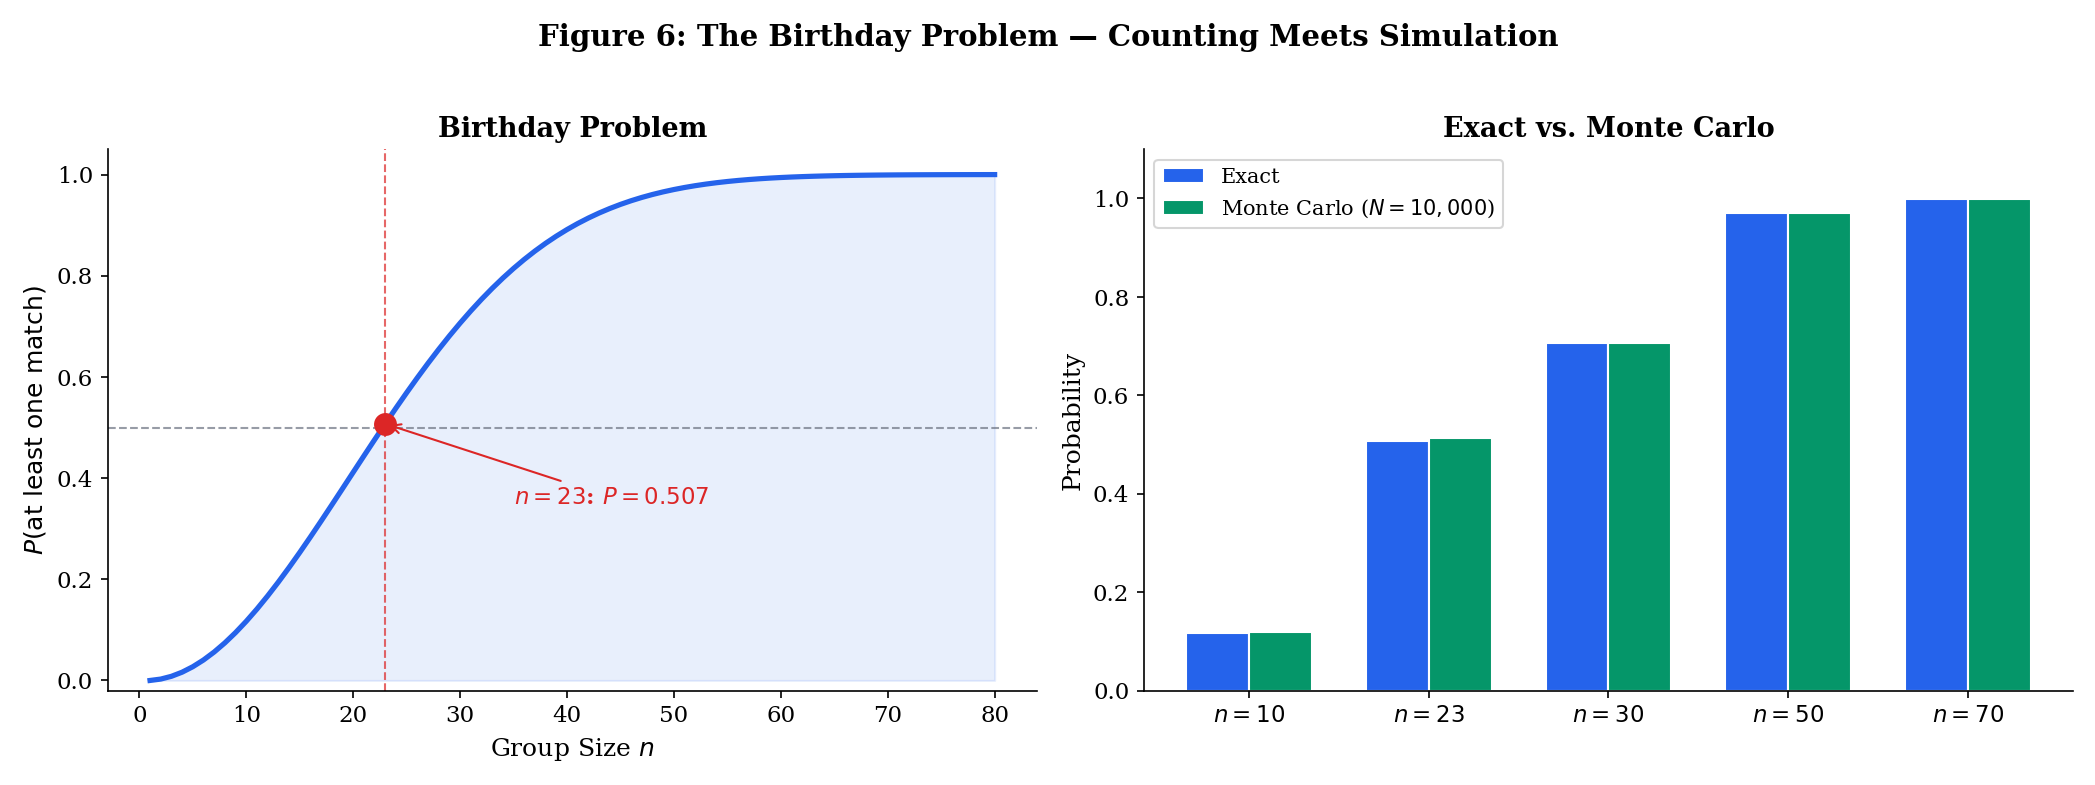

Birthday Problem — Exact vs Monte Carlo
    n      Exact         MC    |Error|
----------------------------------------
   10     0.1169     0.1189     0.0020
   23     0.5073     0.5126     0.0053
   30     0.7063     0.7063     0.0000
   50     0.9704     0.9698     0.0006
   70     0.9992     0.9995     0.0003


In [7]:
# ── Figure 6: The Birthday Problem ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exact computation
def birthday_probability(n: int, days: int = 365) -> float:
    """P(at least one shared birthday) in a group of n people."""
    if n > days:
        return 1.0
    p_all_different = 1.0
    for k in range(n):
        p_all_different *= (days - k) / days
    return 1.0 - p_all_different

n_values = np.arange(1, 81)
probs = [birthday_probability(n) for n in n_values]

# Panel 1: P(match) vs group size
ax = axes[0]
ax.plot(n_values, probs, color=C['primary'], linewidth=2.5)
ax.axhline(y=0.5, color=C['muted'], linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(x=23, color=C['danger'], linestyle='--', linewidth=1, alpha=0.7)
ax.plot(23, birthday_probability(23), 'o', color=C['danger'], markersize=10, zorder=5)
ax.annotate(f'$n = 23$: $P = {birthday_probability(23):.3f}$',
            xy=(23, birthday_probability(23)),
            xytext=(35, 0.35),
            fontsize=11,
            arrowprops=dict(arrowstyle='->', color=C['danger']),
            color=C['danger'], fontweight='bold')
ax.fill_between(n_values, 0, probs, alpha=0.1, color=C['primary'])
ax.set_xlabel('Group Size $n$', fontsize=12)
ax.set_ylabel('$P(\mathrm{at\ least\ one\ match})$', fontsize=12)
ax.set_title('Birthday Problem', fontsize=13)
ax.set_ylim(-0.02, 1.05)

# Panel 2: Monte Carlo simulation verification
ax = axes[1]
np.random.seed(42)
n_sims = 10000
group_sizes = [10, 23, 30, 50, 70]
mc_probs = []
for n in group_sizes:
    matches = 0
    for _ in range(n_sims):
        birthdays = np.random.randint(0, 365, size=n)
        if len(set(birthdays)) < n:
            matches += 1
    mc_probs.append(matches / n_sims)

exact_probs = [birthday_probability(n) for n in group_sizes]

x_pos = np.arange(len(group_sizes))
width = 0.35
bars1 = ax.bar(x_pos - width/2, exact_probs, width, label='Exact',
               color=C['primary'], edgecolor='white')
bars2 = ax.bar(x_pos + width/2, mc_probs, width, label=f'Monte Carlo ($N={n_sims:,}$)',
               color=C['accent'], edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'$n={n}$' for n in group_sizes])
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Exact vs. Monte Carlo', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)

plt.suptitle('Figure 6: The Birthday Problem — Counting Meets Simulation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('birthday-problem.png', dpi=150, bbox_inches='tight')
plt.show()

# Print verification table
print("Birthday Problem — Exact vs Monte Carlo")
print(f"{'n':>5} {'Exact':>10} {'MC':>10} {'|Error|':>10}")
print("-" * 40)
for n, ex, mc in zip(group_sizes, exact_probs, mc_probs):
    print(f"{n:>5} {ex:>10.4f} {mc:>10.4f} {abs(ex - mc):>10.4f}")

### 6.4 Inclusion-Exclusion in Action: The Matching Problem (Derangements)

**Example 7 (The Hat-Check Problem).** $n$ people check their hats; the hats are returned at random. What is the probability that *nobody* gets their own hat back?

A permutation with no fixed points is called a **derangement**. Let $A_i$ be the event "person $i$ gets their own hat." We want $P\left(\bigcup_{i=1}^n A_i\right)^c = 1 - P\left(\bigcup_{i=1}^n A_i\right)$.

By inclusion-exclusion:
$$P\left(\bigcup_{i=1}^n A_i\right) = \sum_{k=1}^n (-1)^{k+1} \binom{n}{k} \cdot \frac{(n-k)!}{n!} = \sum_{k=1}^n \frac{(-1)^{k+1}}{k!}.$$

So the probability of a derangement is:
$$P(\text{derangement}) = 1 - \sum_{k=1}^n \frac{(-1)^{k+1}}{k!} = \sum_{k=0}^n \frac{(-1)^k}{k!} \xrightarrow{n \to \infty} \frac{1}{e} \approx 0.3679.$$

This is remarkable: for large $n$, the probability converges to $1/e$, independent of $n$. The convergence is extremely fast — already at $n = 5$, the answer is accurate to three decimal places.

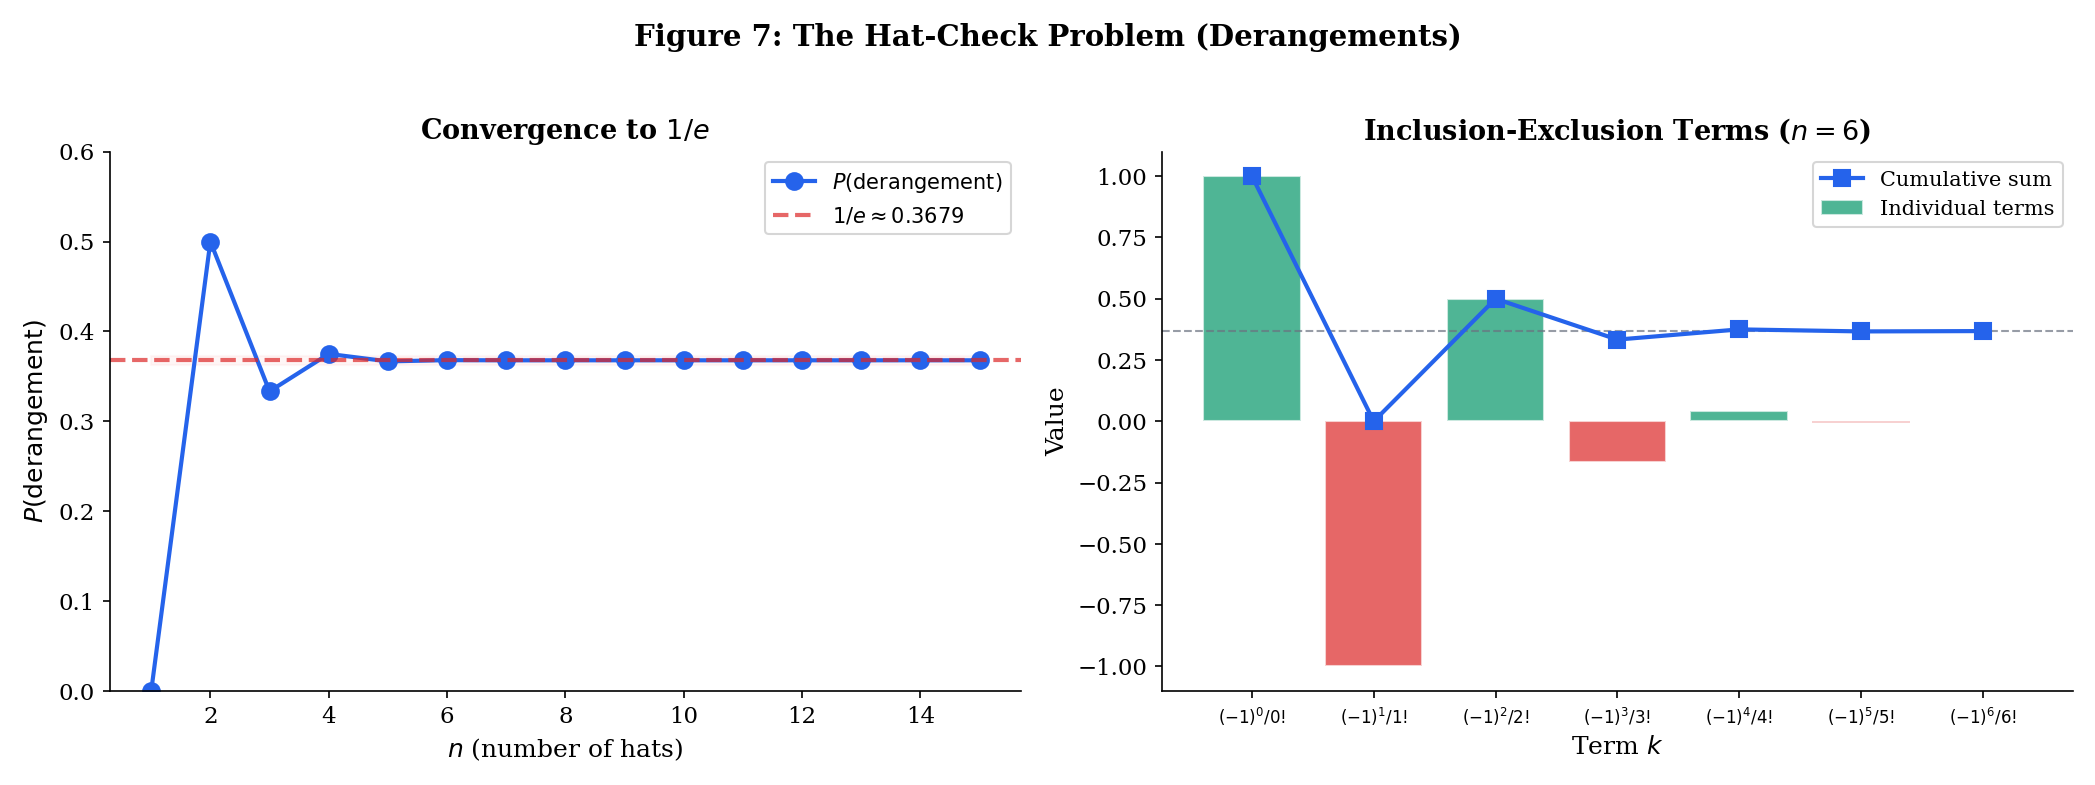


1/e = 0.3678794412
P(derangement, n=10) = 0.3678794643
|Difference| = 2.31e-08


In [8]:
# ── Figure 7: Derangements and convergence to 1/e ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exact derangement count
def count_derangements(n: int) -> int:
    """Count derangements of n elements using inclusion-exclusion."""
    return round(sum((-1)**k * factorial(n) // factorial(k) for k in range(n + 1)))

def derangement_probability(n: int) -> float:
    """P(derangement) = D(n) / n!"""
    return sum((-1)**k / factorial(k) for k in range(n + 1))

# Panel 1: P(derangement) converging to 1/e
ax = axes[0]
ns = np.arange(1, 16)
d_probs = [derangement_probability(n) for n in ns]

ax.plot(ns, d_probs, 'o-', color=C['primary'], linewidth=2, markersize=8,
        label='$P(\mathrm{derangement})$')
ax.axhline(y=1/np.e, color=C['danger'], linestyle='--', linewidth=2, alpha=0.7,
           label=r'$1/e \approx 0.3679$')

# Shade convergence band
ax.fill_between(ns, 1/np.e - 0.005, 1/np.e + 0.005, color=C['lt_red'], alpha=0.3)

ax.set_xlabel('$n$ (number of hats)', fontsize=12)
ax.set_ylabel('$P(\mathrm{derangement})$', fontsize=12)
ax.set_title('Convergence to $1/e$', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.6)

# Panel 2: Inclusion-exclusion terms
ax = axes[1]
n_demo = 6
terms = [(-1)**k / factorial(k) for k in range(n_demo + 1)]
cumulative = np.cumsum(terms)

ax.bar(range(n_demo + 1), terms, color=[C['accent'] if t >= 0 else C['danger'] for t in terms],
       edgecolor='white', linewidth=1, alpha=0.7, label='Individual terms')
ax.plot(range(n_demo + 1), cumulative, 's-', color=C['primary'], linewidth=2,
        markersize=8, label='Cumulative sum', zorder=5)
ax.axhline(y=1/np.e, color=C['muted'], linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('Term $k$', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(f'Inclusion-Exclusion Terms ($n = {n_demo}$)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(range(n_demo + 1))
ax.set_xticklabels([f'$(-1)^{k}/{k}!$' for k in range(n_demo + 1)], fontsize=8)

plt.suptitle('Figure 7: The Hat-Check Problem (Derangements)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('derangements.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n1/e = {1/np.e:.10f}")
print(f"P(derangement, n=10) = {derangement_probability(10):.10f}")
print(f"|Difference| = {abs(derangement_probability(10) - 1/np.e):.2e}")

---

## 7. Conditional Probability & Independence (Preview)

We close the mathematical content with a brief preview of the next topic. Conditional probability answers: "given that event $B$ has occurred, what is the probability of event $A$?"

**Definition 5 (Conditional Probability, preview).** For events $A, B \in \mathcal{F}$ with $P(B) > 0$,
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}.$$

**Definition 6 (Independence, preview).** Events $A$ and $B$ are *independent* if
$$P(A \cap B) = P(A) \cdot P(B).$$

Equivalently (when $P(B) > 0$): $P(A \mid B) = P(A)$ — knowing $B$ occurred doesn't change the probability of $A$.

These concepts are the subject of the next topic in Track 1. We'll prove Bayes' theorem, develop the law of total probability, and explore the surprisingly subtle concept of conditional independence — the assumption behind naïve Bayes classifiers, graphical models, and essentially all tractable probabilistic inference.

---

## 8. Connections to ML

### 8.1 Probability Spaces in Disguise

Every ML model implicitly defines a probability space:

| ML Model | Sample Space $\Omega$ | $\sigma$-Algebra $\mathcal{F}$ | Probability $P$ |
|---|---|---|---|
| Bernoulli classifier | $\{0, 1\}$ | $\mathcal{P}(\{0,1\})$ | $P(Y=1) = \sigma(w^\top x)$ |
| Multinomial (softmax) | $\{1, \ldots, K\}$ | $\mathcal{P}(\{1,\ldots,K\})$ | Softmax output |
| Gaussian model | $\mathbb{R}$ | $\mathcal{B}(\mathbb{R})$ | $\mathcal{N}(\mu, \sigma^2)$ |
| Language model | Token sequences | Cylinder $\sigma$-algebra | Autoregressive factorization |
| Diffusion model | $\mathbb{R}^d$ | $\mathcal{B}(\mathbb{R}^d)$ | Learned via score matching |

### 8.2 The Union Bound in Learning Theory

Boole's inequality (Theorem 5) is the entry point to PAC learning. The core argument:

1. You have $|\mathcal{H}|$ hypotheses (models).
2. For each $h \in \mathcal{H}$, define $A_h$ = "hypothesis $h$ overfits" (training error is small but true error is large).
3. You want $P(\text{some hypothesis overfits}) = P\left(\bigcup_h A_h\right) \leq \delta$.
4. By the union bound: $P\left(\bigcup_h A_h\right) \leq \sum_h P(A_h)$.
5. So it suffices to make $P(A_h) \leq \delta / |\mathcal{H}|$ for each $h$.

This is the simplest version of the *uniform convergence* argument. It tells you that generalization requires either few hypotheses or very tight per-hypothesis bounds — the fundamental tension of statistical learning theory.

### 8.3 Sigma-Algebras and Information

In Bayesian ML, the $\sigma$-algebra encodes *what you can observe*. A filtration $\mathcal{F}_0 \subseteq \mathcal{F}_1 \subseteq \cdots$ models *information arriving over time*:

- In online learning, $\mathcal{F}_t$ is the information available after seeing $t$ data points.
- In reinforcement learning, $\mathcal{F}_t$ is the history up to time $t$ (all states, actions, rewards).
- In time series, $\mathcal{F}_t$ is the natural filtration of the observed process.

This seems abstract now, but when we get to martingales and stochastic processes later in formalStatistics, filtrations will be the language we use to formalize "what the model knows at each step." 

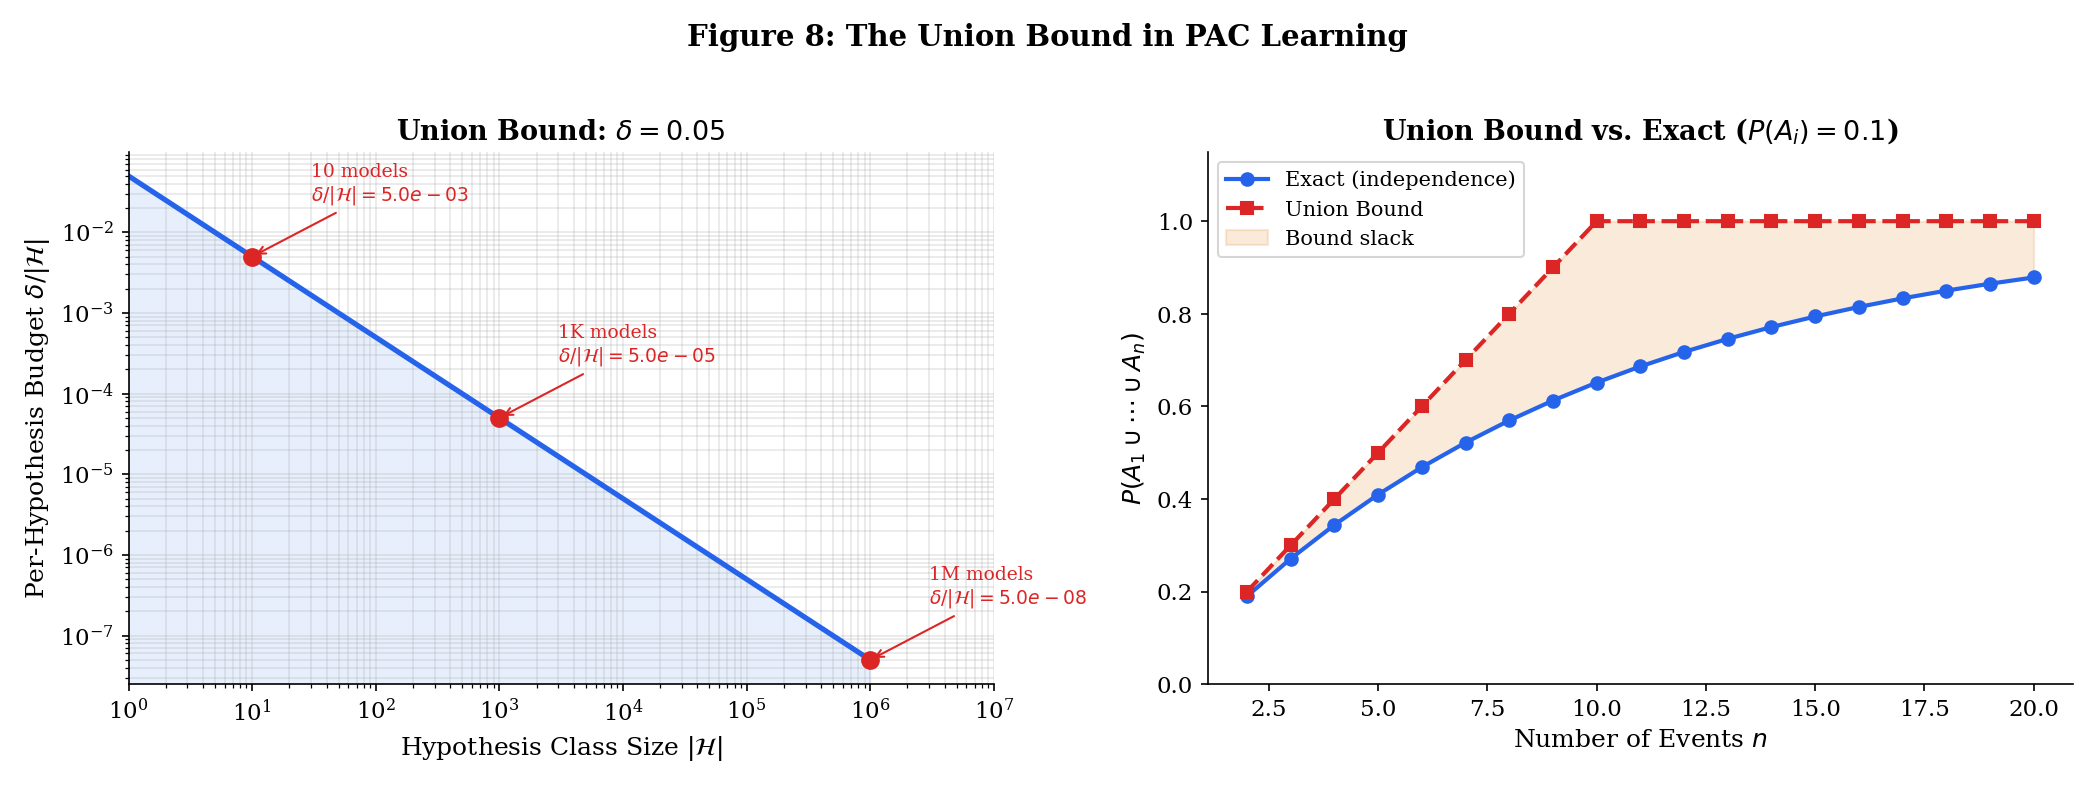

In [9]:
# ── Figure 8: Union bound in PAC learning ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Union bound — required per-hypothesis error budget
ax = axes[0]
delta = 0.05  # Overall error tolerance
hypothesis_counts = np.logspace(0, 6, 100)
per_hypothesis_budget = delta / hypothesis_counts

ax.loglog(hypothesis_counts, per_hypothesis_budget, color=C['primary'], linewidth=2.5)
ax.fill_between(hypothesis_counts, per_hypothesis_budget, alpha=0.1, color=C['primary'])
ax.set_xlabel('Hypothesis Class Size $|\mathcal{H}|$', fontsize=12)
ax.set_ylabel('Per-Hypothesis Budget $\delta / |\mathcal{H}|$', fontsize=12)
ax.set_title(f'Union Bound: $\delta = {delta}$', fontsize=13)

# Annotate key points
for h_size, label in [(10, '10 models'), (1000, '1K models'), (1e6, '1M models')]:
    budget = delta / h_size
    ax.plot(h_size, budget, 'o', color=C['danger'], markersize=8, zorder=5)
    ax.annotate(f'{label}\n$\delta/|\mathcal{{H}}|={budget:.1e}$',
                xy=(h_size, budget), xytext=(h_size * 3, budget * 5),
                fontsize=9, arrowprops=dict(arrowstyle='->', color=C['danger']),
                color=C['danger'])

ax.set_xlim(1, 1e7)
ax.grid(True, alpha=0.3, which='both')

# Panel 2: Inclusion-exclusion vs union bound — accuracy comparison
ax = axes[1]
n_events = np.arange(2, 21)
p_each = 0.1  # P(A_i) for each event, assumed independent

# Exact (independence): P(union) = 1 - (1-p)^n
exact = 1 - (1 - p_each) ** n_events
# Union bound: sum of P(A_i)
union_bound = n_events * p_each
# Clamp to 1
union_bound_clamped = np.minimum(union_bound, 1.0)

ax.plot(n_events, exact, 'o-', color=C['primary'], linewidth=2, label='Exact (independence)')
ax.plot(n_events, union_bound_clamped, 's--', color=C['danger'], linewidth=2,
        label='Union Bound')
ax.fill_between(n_events, exact, union_bound_clamped, alpha=0.15, color=C['warning'],
                label='Bound slack')

ax.set_xlabel('Number of Events $n$', fontsize=12)
ax.set_ylabel('$P(A_1 \cup \cdots \cup A_n)$', fontsize=12)
ax.set_title(f'Union Bound vs. Exact ($P(A_i) = {p_each}$)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)

plt.suptitle('Figure 8: The Union Bound in PAC Learning', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('union-bound-pac.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 9. Computational Verification

We verify the key results computationally — both to confirm the mathematics and to build intuition through simulation.

In [10]:
# ── 9.1 Verify axioms on a finite probability space ──────────────────────────

class FiniteProbabilitySpace:
    """A probability space on a finite sample space with equally likely outcomes."""
    
    def __init__(self, outcomes: list):
        self.omega = set(outcomes)
        self.n = len(self.omega)
    
    def P(self, event: set) -> float:
        """Probability of an event (subset of omega)."""
        assert event.issubset(self.omega), f"Event {event} is not a subset of Ω"
        return len(event) / self.n
    
    def verify_axioms(self) -> None:
        """Verify the three Kolmogorov axioms."""
        from itertools import chain, combinations
        
        def powerset(s):
            return list(chain.from_iterable(combinations(s, r) for r in range(len(s)+1)))
        
        all_events = [set(s) for s in powerset(self.omega)]
        
        # Axiom 1: Non-negativity
        axiom1 = all(self.P(A) >= 0 for A in all_events)
        print(f"Axiom 1 (Non-negativity):    {'✓' if axiom1 else '✗'}")
        
        # Axiom 2: Normalization
        axiom2 = abs(self.P(self.omega) - 1.0) < 1e-12
        print(f"Axiom 2 (Normalization):     {'✓' if axiom2 else '✗'}  P(Ω) = {self.P(self.omega)}")
        
        # Axiom 3: Finite additivity (check for all disjoint pairs)
        axiom3 = True
        for A in all_events:
            for B in all_events:
                if A.isdisjoint(B):
                    if abs(self.P(A | B) - (self.P(A) + self.P(B))) > 1e-12:
                        axiom3 = False
                        break
        print(f"Axiom 3 (Finite additivity): {'✓' if axiom3 else '✗'}")

# Fair die
print("=== Fair Die ===")
die = FiniteProbabilitySpace([1, 2, 3, 4, 5, 6])
die.verify_axioms()

# Verify specific events
A = {2, 4, 6}  # Even
B = {5, 6}     # At least 5
print(f"\nP(even) = {die.P(A):.4f}")
print(f"P(≥5) = {die.P(B):.4f}")
print(f"P(even ∩ ≥5) = {die.P(A & B):.4f}")
print(f"P(even ∪ ≥5) = {die.P(A | B):.4f}")
print(f"Addition rule check: P(A) + P(B) - P(A∩B) = {die.P(A) + die.P(B) - die.P(A & B):.4f}")

=== Fair Die ===
Axiom 1 (Non-negativity):    ✓
Axiom 2 (Normalization):     ✓  P(Ω) = 1.0
Axiom 3 (Finite additivity): ✓

P(even) = 0.5000
P(≥5) = 0.3333
P(even ∩ ≥5) = 0.1667
P(even ∪ ≥5) = 0.6667
Addition rule check: P(A) + P(B) - P(A∩B) = 0.6667


In [11]:
# ── 9.2 Monte Carlo verification of inclusion-exclusion ──────────────────────

np.random.seed(42)

def monte_carlo_union_prob(n_events: int, p_each: float, n_sims: int = 100000,
                           independent: bool = True) -> Tuple[float, float]:
    """Estimate P(A1 ∪ ... ∪ An) by simulation. Return (MC estimate, exact)."""
    if independent:
        # Each event occurs independently with probability p_each
        events = np.random.random((n_sims, n_events)) < p_each
        union_occurred = events.any(axis=1)
        mc_estimate = union_occurred.mean()
        exact = 1 - (1 - p_each)**n_events
    else:
        raise NotImplementedError("Correlated events not implemented")
    return mc_estimate, exact

print("Monte Carlo Verification of Union Probabilities")
print(f"{'n':>5} {'p':>6} {'MC':>10} {'Exact':>10} {'Union Bd':>10} {'|MC-Exact|':>10}")
print("-" * 55)
for n in [2, 5, 10, 20]:
    for p in [0.05, 0.1, 0.2]:
        mc, exact = monte_carlo_union_prob(n, p, n_sims=200000)
        ub = min(n * p, 1.0)
        print(f"{n:>5} {p:>6.2f} {mc:>10.4f} {exact:>10.4f} {ub:>10.4f} {abs(mc-exact):>10.4f}")

Monte Carlo Verification of Union Probabilities
    n      p         MC      Exact   Union Bd |MC-Exact|
-------------------------------------------------------
    2   0.05     0.0967     0.0975     0.1000     0.0008
    2   0.10     0.1880     0.1900     0.2000     0.0020
    2   0.20     0.3593     0.3600     0.4000     0.0007
    5   0.05     0.2273     0.2262     0.2500     0.0011
    5   0.10     0.4092     0.4095     0.5000     0.0003
    5   0.20     0.6733     0.6723     1.0000     0.0010
   10   0.05     0.4004     0.4013     0.5000     0.0009
   10   0.10     0.6521     0.6513     1.0000     0.0008
   10   0.20     0.8931     0.8926     1.0000     0.0005
   20   0.05     0.6401     0.6415     1.0000     0.0014
   20   0.10     0.8786     0.8784     1.0000     0.0002
   20   0.20     0.9889     0.9885     1.0000     0.0005


In [12]:
# ── 9.3 Verify continuity of probability via simulation ──────────────────────

np.random.seed(42)

# Increasing sequence: A_n = [0, n/(n+1)] ⊂ [0,1], so P(A_n) = n/(n+1) → 1
# Decreasing sequence: B_n = [0, 1/n] ⊂ [0,1], so P(B_n) = 1/n → 0

n_sims = 200000
samples = np.random.uniform(0, 1, n_sims)

print("Continuity of Probability — Simulation")
print(f"\nIncreasing sequence: A_n = [0, n/(n+1)]")
print(f"{'n':>5} {'Theory':>10} {'MC':>10} {'|Error|':>10}")
print("-" * 40)
for n in [1, 2, 5, 10, 50, 100]:
    theory = n / (n + 1)
    mc = np.mean(samples <= n / (n + 1))
    print(f"{n:>5} {theory:>10.6f} {mc:>10.6f} {abs(theory - mc):>10.6f}")

print(f"\nDecreasing sequence: B_n = [0, 1/n]")
print(f"{'n':>5} {'Theory':>10} {'MC':>10} {'|Error|':>10}")
print("-" * 40)
for n in [1, 2, 5, 10, 50, 100]:
    theory = 1 / n
    mc = np.mean(samples <= 1 / n)
    print(f"{n:>5} {theory:>10.6f} {mc:>10.6f} {abs(theory - mc):>10.6f}")

print(f"\nP(A_n) → P(A) = 1: confirmed by monotone convergence")
print(f"P(B_n) → P(B) = 0: confirmed by monotone convergence")

Continuity of Probability — Simulation

Increasing sequence: A_n = [0, n/(n+1)]
    n     Theory         MC    |Error|
----------------------------------------
    1   0.500000   0.498840   0.001160
    2   0.666667   0.666380   0.000287
    5   0.833333   0.833280   0.000053
   10   0.909091   0.909615   0.000524
   50   0.980392   0.980730   0.000338
  100   0.990099   0.990215   0.000116

Decreasing sequence: B_n = [0, 1/n]
    n     Theory         MC    |Error|
----------------------------------------
    1   1.000000   1.000000   0.000000
    2   0.500000   0.498840   0.001160
    5   0.200000   0.199745   0.000255
   10   0.100000   0.100100   0.000100
   50   0.020000   0.019680   0.000320
  100   0.010000   0.009845   0.000155

P(A_n) → P(A) = 1: confirmed by monotone convergence
P(B_n) → P(B) = 0: confirmed by monotone convergence


---

## Summary

| Concept | Key Idea |
|---|---|
| **Sample space** $\Omega$ | The set of all possible outcomes |
| **Event** $A \subseteq \Omega$ | A subset of outcomes; "something we can ask about" |
| **$\sigma$-algebra** $\mathcal{F}$ | The collection of "askable" events — closed under complements and countable unions |
| **Probability measure** $P$ | A function $P : \mathcal{F} \to [0,1]$ satisfying non-negativity, normalization, and countable additivity |
| **Probability space** $(\Omega, \mathcal{F}, P)$ | The complete specification of a probabilistic model |
| **Complement rule** | $P(A^c) = 1 - P(A)$ |
| **Addition rule** | $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ |
| **Union bound** | $P(\bigcup A_n) \leq \sum P(A_n)$ — the workhorse of PAC learning |
| **Continuity** | $A_n \uparrow A \Rightarrow P(A_n) \to P(A)$ — why countable additivity matters |
| **Combinatorial probability** | $P(A) = |A| / |\Omega|$ when outcomes are equally likely |

### What's Next

The next topic — **Conditional Probability & Independence** — builds on this foundation to answer: "how does new information change probabilities?" We'll derive Bayes' theorem, formalize independence, and see why conditional independence is the structural assumption that makes probabilistic ML tractable.

### References

1. Billingsley, P. (2012). *Probability and Measure* (Anniversary ed.). Wiley.
2. Durrett, R. (2019). *Probability: Theory and Examples* (5th ed.). Cambridge University Press.
3. Grimmett, G. & Stirzaker, D. (2020). *Probability and Random Processes* (4th ed.). Oxford University Press.
4. Wasserman, L. (2004). *All of Statistics*. Springer.
5. Shalev-Shwartz, S. & Ben-David, S. (2014). *Understanding Machine Learning: From Theory to Algorithms*. Cambridge University Press.

---

*Notebook for formalStatistics — [formalstatistics.com](https://www.formalstatistics.com)*  
*Author: Jonathan Rocha | DataSalt LLC*